
# FSC ↔ tinyRNN pipeline

Two independent ways of extracting a **minimal, interpretable model of decision-making**
from the same behavioral data:

1. **Finite State Controller (FSC)** — Nicoletti & Celani, *"Decoding behavior with
   minimal and interpretable agent models"* (2026). A discrete-state controller fit by
   MAPSO (particle-swarm) + gradient descent.
   Code: [`FSC-inference-MAPSO`](https://github.com/giorgionicoletti/FSC-inference-MAPSO)
2. **tinyRNN** — Ji-An, Benna & Mattar, *"Discovering cognitive strategies with tiny
   recurrent neural networks"* (Nature, 2025). A small GRU trained with the paper's
   official nested cross-validation procedure to find the smallest RNN that explains
   the behavior.
   Code: [`tinyRNN`](https://github.com/cgc/tinyRNN)

## A note on fidelity
Both repos are vendored (git-cloned) rather than reimplemented, and the training /
inference calls below follow the authors' own example notebooks / experiment scripts
as closely as possible, so that nothing about *how* the models are fit is invented here.


- **The "free experiments" section (Section 4)** is analysis code we write ourselves.
  Where it touches the FSC's internal dynamics (the belief-state decoder), it is a
  direct implementation of the same forward-filtering recursion the library itself
  computes inside `inference.loss` (see Section 4.1), not a new model.

## Reproducibility — how someone else runs this
The two upstream repos are **not** committed to this project's repo; Section 0 `git clone`s
them fresh (`--depth 1`) into `FSC-inference-MAPSO/` and `tinyRNN/`. So a fresh checkout of
this project is just the notebook, the `wsls_actions_observations.npz` data, and the
`fitted_models/` artifacts — you run Section 0 once and the libraries appear locally.

The **only** modifications made to those cloned libraries are two automated patches that
Section 0 applies itself (idempotently) each run:
1. `path_settings.py` — replace the upstream hardcoded Windows `MODEL_SAVE_PATH` with a
   local relative path, so the notebook is portable.
2. `datasets/SimpleDataset.py` — a one-line upstream bug fix for variable-length sessions.

Because both patches live in the notebook (not hand-edits made outside it), a fresh clone +
run reproduces them exactly — nothing about the fitted models depends on manual edits.
The `fitted_models/` directory ships the already-fit results (FSC sweep + the full RNN
nested-CV) so you can explore Sections 2.3/3.3 onward without re-running the (slow) fits;
delete it (or flip the `FORCE_*` toggles) to regenerate from scratch.

## Requirements
Python ≥3.9, and (installed in Section 0): `torch`, `numpy`, `scipy`, `pandas`,
`scikit-learn`, `statsmodels`, `numba`, `networkx`, `joblib`, `matplotlib`, `tqdm`.
tinyRNN training is CPU-friendly for small hidden sizes but will be much faster on GPU
for larger sweeps / real datasets — hence this notebook is meant to be run on your own
machine or Colab rather than in-chat.


## 0. Setup — clone repos, install dependencies, patch paths

In [1]:

# Clone both repos (skips if already present, e.g. re-running this cell)
import os, subprocess

REPOS = {
    "FSC-inference-MAPSO": "https://github.com/giorgionicoletti/FSC-inference-MAPSO.git",
    "tinyRNN": "https://github.com/cgc/tinyRNN.git",
}
for name, url in REPOS.items():
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", url, name], check=True)
    else:
        print(f"{name} already present, skipping clone.")


FSC-inference-MAPSO already present, skipping clone.
tinyRNN already present, skipping clone.


In [2]:

# Install dependencies (skip/comment out any you already have, e.g. torch with CUDA)
import sys
%pip install -q torch numpy scipy pandas scikit-learn statsmodels numba networkx joblib matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [3]:

# --- Patch 1: point tinyRNN's MODEL_SAVE_PATH at a local relative folder -----------
# The repo ships with a hardcoded Windows path (D:\...); we override it so the
# notebook is portable. This is exactly the kind of thing path_settings.py is meant
# for (the file is literally called "user-specific settings").
path_settings_file = "tinyRNN/path_settings.py"
with open(path_settings_file) as f:
    content = f.read()
content = content.replace(
    r"MODEL_SAVE_PATH = Path('D:\\cognitive_dynamics\\saved_model')",
    "MODEL_SAVE_PATH = Path('./files/saved_model')",
)
with open(path_settings_file, "w") as f:
    f.write(content)
print("Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model")


Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model


In [4]:

# --- Patch 2: upstream bug fix in SimpleDataset.py ---------------------------------
# SimpleDataset._behav_to_tensor computes `invalid = value == -1` on a per-session
# array of length `trial_count`, then does `mask[b, invalid] = 0` where `mask`'s
# second axis has length `trial_num` (the length of the LONGEST session, used for
# padding). Whenever a session is shorter than the longest one (i.e. real behavioral
# data with variable trial counts per session), the boolean array length doesn't
# match the array being indexed and this throws an IndexError.
# Fix: index with `idxs[invalid]` (idxs = np.arange(trial_count)) instead of `invalid`
# directly, so the boolean mask is applied to the correct sub-range.
simple_dataset_file = "tinyRNN/datasets/SimpleDataset.py"
with open(simple_dataset_file) as f:
    content = f.read()
buggy = "                invalid = value == -1\n                mask[b, invalid] = 0"
fixed = "                invalid = value == -1\n                mask[b, idxs[invalid]] = 0"
if buggy in content:
    content = content.replace(buggy, fixed)
    with open(simple_dataset_file, "w") as f:
        f.write(content)
    print("Patched tinyRNN/datasets/SimpleDataset.py (variable-length-session bug fix).")
elif fixed in content:
    print("SimpleDataset.py already patched.")
else:
    print("WARNING: expected code not found — SimpleDataset.py may have changed upstream. "
          "If you hit an IndexError in Section 3, look for the 'invalid'/'mask' lines "
          "in datasets/SimpleDataset.py and apply the same fix by hand.")


SimpleDataset.py already patched.


In [5]:
import sys, os
import pickle
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --- Both repos define top-level modules with the SAME NAME ('utils', and for FSC
# also 'parametrizations'/'MAPSO'/'environments'/'DiscreteObs'). They can't both sit
# on sys.path at the same time without one shadowing the other, so we switch between
# them explicitly (using absolute paths, since cwd changes later when we `os.chdir`
# into tinyRNN in Section 3).
FSC_SRC = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING_MODULE_NAMES = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path:
        sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:
        sys.path.insert(0, FSC_SRC)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:
        sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path:
        sys.path.insert(0, TINYRNN_ROOT)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

_use_fsc_path()
import FSC as fsc_lib   # from FSC-inference-MAPSO

print("Imports OK")

Imports OK



## 1. Data input

**Canonical format used throughout this notebook:** a list of *sessions* (a session =
one continuous behavioral episode / recording block). Each session is a `dict`:

```python
{
    "actions":      [...],   # length-T sequence, one action per trial
    "observations": [...],   # length-T sequence, one observation per trial
    "reward":       [...],   # OPTIONAL, length-T sequence
}
```

Values can be ints, strings, or floats-that-are-really-categories — they get encoded
into integer indices in Section 1.2. Sessions can have **different lengths** (that's
the whole point of the bug fix in Section 0).

Three ways to get your data into this format — **use whichever matches what you have**:
- **1.1a** — already have a list of dicts like the above (e.g. built from a pickle /
  your own loader) → skip straight to Section 1.2.
- **1.1b** — a long-format CSV: one row per trial, with a session-id column, an
  action column, an observation column, and (optionally) a reward column.
- **1.1c** — no real data yet → generates a small synthetic task so you can run the
  whole notebook end to end and sanity-check the pipeline before plugging in real data.

Only run **one** of 1.1a/1.1b/1.1c.


In [6]:
# --- 1.1a — WSLS dataset -------------------------------------------------------------
# What the columns mean (verified empirically from this file):
#   actions      in {-1, +1}: which of two options was chosen on each trial.
#   observations in {0, 1}:   the OUTCOME of that trial (1 = win / rewarded, 0 = lose).
# The data is exact win-stay-lose-shift: observation[t]==1 -> the next action repeats
# (stay); observation[t]==0 -> the next action switches. So observation[t] is the result
# of action[t] (known only AFTER it), and it deterministically drives action[t+1].
# NOTE on the two model conventions: the RNN predicts action[t] from strictly earlier
# trials (it never sees observation[t] when predicting action[t]); the FSC's likelihood
# formally conditions action[t] on observation[t]. For THIS data that difference is
# harmless (action[t] is independent of observation[t]; corr ~= 0.001 -- the predictive
# information lives in observation[t-1], which both models carry in state/memory), but on
# a task where the observation is a pre-action stimulus the distinction matters -- keep it
# in mind before reading too much into the head-to-head loss in Section 3.5.
wsls = np.load("wsls_actions_observations.npz")
wsls_actions = wsls["actions"]        # shape (100000, 200)
wsls_observations = wsls["observations"]

N_SESSIONS_TO_USE = 1000   # subsampled from 100,000 -- raise this if accuracy is too low
idx = np.arange(wsls_actions.shape[0]) if N_SESSIONS_TO_USE is None \
      else np.random.default_rng(0).choice(wsls_actions.shape[0], N_SESSIONS_TO_USE, replace=False)

sessions = [
    {"actions": wsls_actions[i], "observations": wsls_observations[i]}
    for i in idx
]
print(f"Loaded {len(sessions)} sessions of {wsls_actions.shape[1]} trials each")

Loaded 1000 sessions of 200 trials each


In [7]:

# # --- 1.1b — Long-format CSV ---------------------------------------------------------
# def load_sessions_from_long_csv(csv_path, session_col, action_col, obs_col, reward_col=None):
#     '''One row per trial. Groups rows by `session_col`, preserving row order within
#     each session (does NOT re-sort by any timestamp — make sure your CSV rows are
#     already in trial order within each session).'''
#     df = pd.read_csv(csv_path)
#     sessions = []
#     for _, g in df.groupby(session_col, sort=False):
#         session = {
#             "actions": g[action_col].to_numpy(),
#             "observations": g[obs_col].to_numpy(),
#         }
#         if reward_col is not None:
#             session["reward"] = g[reward_col].to_numpy()
#         sessions.append(session)
#     return sessions

# # Example (edit paths/column names for your file, then uncomment):
# # sessions = load_sessions_from_long_csv(
# #     "my_behavior.csv",
# #     session_col="session_id", action_col="action", obs_col="observation", reward_col="reward",
# # )


In [8]:

# # --- 1.1c — Synthetic demo data (OPTIONAL — for testing the pipeline only) ---------
# # A simple 2-action / 3-observation task with real trial-to-trial structure (so the
# # FSC / RNN have something non-trivial to find), used only so you can run this
# # notebook end-to-end before you have real data wired in. Comment this cell out once
# # you're using 1.1a or 1.1b.
# def generate_synthetic_demo_sessions(n_sessions=40, min_T=40, max_T=80, seed=0):
#     rng = np.random.default_rng(seed)
#     sessions = []
#     for _ in range(n_sessions):
#         T = rng.integers(min_T, max_T)
#         obs = rng.integers(0, 3, size=T)          # 3 possible observations
#         actions = np.zeros(T, dtype=int)
#         reward = np.zeros(T, dtype=int)
#         counter = 0
#         for t in range(T):
#             counter += obs[t]
#             actions[t] = counter % 2               # parity-check-style rule
#             reward[t] = int(actions[t] == (obs[t] % 2))
#         sessions.append({"actions": actions, "observations": obs, "reward": reward})
#     return sessions

# sessions = generate_synthetic_demo_sessions()
# print(f"Loaded {len(sessions)} synthetic demo sessions "
#       f"(lengths range {min(len(s['actions']) for s in sessions)}-"
#       f"{max(len(s['actions']) for s in sessions)})")


In [9]:

# --- 1.2 — Encoding values from whatever format they are in to integer indices (0,1,2,...) -------------------
def encode_sessions(sessions):
    '''Builds ActSpace/ObsSpace (sorted unique values) and returns integer-encoded
    sessions, so both the FSC and RNN pipelines use IDENTICAL trial-by-trial encoding
    (important later for comparing FSC states to RNN hidden states at matched trials).'''
    all_actions = np.concatenate([np.asarray(s["actions"]) for s in sessions])
    all_obs = np.concatenate([np.asarray(s["observations"]) for s in sessions])
    has_reward = all("reward" in s for s in sessions)

    ActSpace = np.array(sorted(set(all_actions.tolist())))
    ObsSpace = np.array(sorted(set(all_obs.tolist())))
    act_to_idx = {v: i for i, v in enumerate(ActSpace)}
    obs_to_idx = {v: i for i, v in enumerate(ObsSpace)}

    encoded = []
    for s in sessions:
        e = {
            "actions": np.array([act_to_idx[a] for a in s["actions"]], dtype=int),
            "observations": np.array([obs_to_idx[o] for o in s["observations"]], dtype=int),
        }
        if has_reward:
            e["reward"] = np.asarray(s["reward"], dtype=float)
        encoded.append(e)
    return encoded, ActSpace, ObsSpace, has_reward

encoded_sessions, ActSpace, ObsSpace, HAS_REWARD = encode_sessions(sessions)
A, Y = len(ActSpace), len(ObsSpace)
print(f"A (num actions) = {A}, Y (num observations) = {Y}, reward available: {HAS_REWARD}")
print(f"ActSpace = {ActSpace}")
print(f"ObsSpace = {ObsSpace}")


A (num actions) = 2, Y (num observations) = 2, reward available: False
ActSpace = [-1  1]
ObsSpace = [0 1]


In [10]:

# --- 1.3 — Train / test split of SESSIONS (not trials) -----------------------------
# Used by the FSC side for held-out model selection over M in Section 2.
# (The RNN side does its own official nested CV internally in Section 3 — it doesn't
# need this split.)
rng = np.random.default_rng(0)
n_sessions = len(encoded_sessions)
perm = rng.permutation(n_sessions)
n_test = max(1, int(0.2 * n_sessions))
test_idx = set(perm[:n_test].tolist())
train_sessions = [s for i, s in enumerate(encoded_sessions) if i not in test_idx]
test_sessions  = [s for i, s in enumerate(encoded_sessions) if i in test_idx]
print(f"{len(train_sessions)} train sessions, {len(test_sessions)} test sessions")


800 train sessions, 200 test sessions



## 2. Finite State Controller inference

Follows the pattern used in the repo's own demo notebooks (e.g.
`FSC-inference-MAPSO/notebooks/ParityChecker_to_FSC.ipynb`): build a `trajectories`
list of `{"actions", "observations"}` dicts, then for each candidate number of memory
states `M`, fit an `FSC` with MAPSO (supported directly by `set_inference_params`).

Model selection over `M`: fit on `train_sessions`, evaluate held-out negative
log-likelihood on `test_sessions` via `FSC.compute_loss`, and pick the `M` with the
best (or elbow of the) held-out loss — the smallest `M` that's about as good as
larger ones, mirroring how the paper picks a parsimonious number of states.


In [11]:

def sessions_to_fsc_trajectories(sessions):
    return [{"actions": s["actions"], "observations": s["observations"]} for s in sessions]

fsc_train_trajectories = sessions_to_fsc_trajectories(train_sessions)
fsc_test_trajectories  = sessions_to_fsc_trajectories(test_sessions)


In [12]:
# --- 2.1 -- Sweep M ------------------------------------------------------------------
# Fit one FSC per candidate memory-state count M (MAPSO only, no gradient stage), using
# the same MAPSO settings as the repo's ParityChecker_to_FSC.ipynb demo. M=1 is the
# zero-memory baseline: it can't be history-dependent, so it pins the chance level. The
# M range mirrors HIDDEN_DIM_CANDIDATES in 3.2 so the FSC-vs-RNN overlay in 3.5 lines up.
#
# N_EPOCHS_MAPSO -- the compute budget per fit. MAPSO has no early stop, and bolting on a
# training-loss patience break (the RNN's trick in Section 3) would fight it: the late
# S3/S4 stages inject fresh mutations that can still improve the fit, so cutting on a
# plateau risks missing a jump-out. Instead we cap iterations at a value read off the
# 2.1b convergence curve -- on this data every M in the sweep has flattened by ~45
# iterations, so 60 keeps headroom at ~40% less compute than the demo's 100. Re-read 2.1b
# and raise this if you swap in harder data or push M higher. (Single fit per M, no
# restart search: WSLS is near-deterministic so one fit hits the floor; for noisier data
# loop a few restarts and keep the best on fsc_test_trajectories, as MouseBandits does.)
#
# FSC_SWEEP_SEED -- MAPSO draws from the global np.random stream (as the demos do), so we
# reseed per M below to make each fit reproducible regardless of what's already cached.
FSC_SWEEP_SEED = 0
M_CANDIDATES = [2, 3, 4, 5, 6, 7, 8]
N_PARTICLES_MAPSO = 50
N_EPOCHS_MAPSO = 60

# --- Caching: MAPSO fitting is the expensive part of this cell, so each fitted model is
# pickled to disk and reloaded on a later run/kernel-restart instead of being retrained.
# This is just I/O wrapped around the library call, not a change to how the model is fit.
# Set FORCE_REFIT_FSC_SWEEP=True (or delete files in the cache dir) to force a fresh fit --
# e.g. after changing N_EPOCHS_MAPSO / the seed / N_PARTICLES_MAPSO, since the cache is
# keyed only on M and won't notice those. (The shipped cache was fit at the old budget but
# is already fully converged, so refitting at 60 lands on the same loss floor -- the lower
# budget just saves time on future refits.)
FORCE_REFIT_FSC_SWEEP = False # <-- set to True to force a fresh fit
FSC_SWEEP_CACHE_DIR = "fitted_models/fsc/sweep"
os.makedirs(FSC_SWEEP_CACHE_DIR, exist_ok=True)

fitted_fscs = {}
fsc_test_losses = {}

for M in M_CANDIDATES:
    cache_path = os.path.join(FSC_SWEEP_CACHE_DIR, f"fsc_sweep_M{M}.pkl")
    if not FORCE_REFIT_FSC_SWEEP and os.path.exists(cache_path):
        print(f"M={M}: loading cached fit from {cache_path}")
        with open(cache_path, "rb") as f:
            model = pickle.load(f)
    else:
        print(f"\n=== Fitting FSC with M={M} ===")
        np.random.seed(FSC_SWEEP_SEED + M)   # reproducible per-M fit (MAPSO uses global np.random)
        MemSpace = np.array([f"M{i}" for i in range(M)])
        model = fsc_lib.FSC(
            M=M, A=A, Y=Y,
            mode="inference",
            policy_model="softmax",
            policy_params={"theta": None, "zeta": None},
            psi=None,
            ActSpace=np.arange(A), MemSpace=MemSpace, ObsSpace=np.arange(Y),
        )
        model.set_inference_params(
            use_gradient=False, use_MAPSO=True,
            trainable_parameters="all",
            n_particles_MAPSO=N_PARTICLES_MAPSO, NEpochs_MAPSO=N_EPOCHS_MAPSO,
            dynamic_topology_MAPSO=True,
            num_neighbors_init_MAPSO=N_PARTICLES_MAPSO, num_neighbors_final_MAPSO=N_PARTICLES_MAPSO,
            num_neighbors_mid_MAPSO=2,
            init_particles_MAPSO={"distribution": "normal", "mean": 0, "std": 1},
            init_velocities_MAPSO={"distribution": "uniform", "vmin": -0.01, "vmax": 0.01},
            print_params=False,
        )
        model.fit(fsc_train_trajectories, verbose_MAPSO=False, verbose_epochs_MAPSO=True)
        with open(cache_path, "wb") as f:
            pickle.dump(model, f)

    test_loss = model.compute_loss(fsc_test_trajectories)
    fitted_fscs[M] = model
    fsc_test_losses[M] = float(test_loss)
    print(f"M={M}: train best_loss={model.best_loss:.4f}, held-out test loss={test_loss:.4f}")

M=2: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M2.pkl


M=2: train best_loss=0.6931, held-out test loss=1.0594
M=3: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M3.pkl


M=3: train best_loss=0.6931, held-out test loss=0.8598
M=4: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M4.pkl


M=4: train best_loss=0.6931, held-out test loss=0.8029
M=5: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M5.pkl


M=5: train best_loss=0.6931, held-out test loss=0.8096
M=6: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M6.pkl


M=6: train best_loss=0.6931, held-out test loss=0.7938
M=7: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M7.pkl


M=7: train best_loss=0.6931, held-out test loss=0.8018
M=8: loading cached fit from fitted_models/fsc/sweep/fsc_sweep_M8.pkl


M=8: train best_loss=0.6931, held-out test loss=0.8239


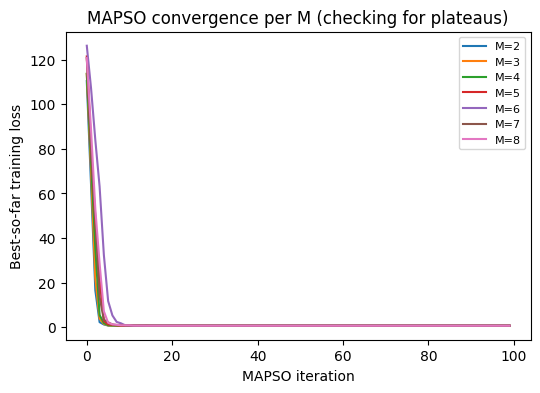

In [13]:
# --- 2.1b -- Diagnostic: did MAPSO plateau before N_EPOCHS_MAPSO? -------------------
# The FSC-inference-MAPSO library has NO built-in early stopping / patience for MAPSO
# (checked its source: the PSO loop in MAPSO.py always runs the full n_iterations, with
# no break-on-no-improvement condition -- by design, since its S3/S4 strategies rely on
# late-stage mutation and "jumping out" to escape local optima, which a naive patience
# check could cut off too early). tinyRNN's RNN training (Section 3) is different: it
# already has real early stopping via 'early_stop_counter' in the base_config.
#
# This curve is where N_EPOCHS_MAPSO in 2.1 comes from: find where the slowest M in your
# sweep flattens, add headroom, cap there. If you change M_CANDIDATES or swap in harder
# data, re-read this plot and retune N_EPOCHS_MAPSO (then FORCE_REFIT / delete the
# affected files in FSC_SWEEP_CACHE_DIR to refit at the new budget).
plt.figure(figsize=(6, 4))
for M in M_CANDIDATES:
    history = fitted_fscs[M].losses_epochs["train"]
    plt.plot(history, label=f"M={M}")
plt.xlabel("MAPSO iteration")
plt.ylabel("Best-so-far training loss")
plt.title("MAPSO convergence per M (checking for plateaus)")
plt.legend(fontsize=8)
plt.show()

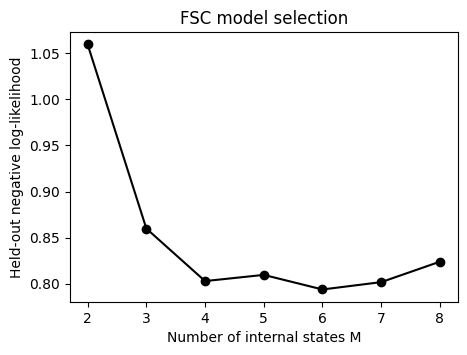

Best M by held-out loss (raw arg-min): M* = 6  (see note above -- a small M within noise of the minimum is usually the more honest / interpretable choice)


In [14]:

# --- 2.2 -- Plot held-out loss vs M, pick M* -----------------------------------------
Ms = sorted(fsc_test_losses)
losses = [fsc_test_losses[m] for m in Ms]

plt.figure(figsize=(5, 3.5))
plt.plot(Ms, losses, "o-", c="k")
plt.xlabel("Number of internal states M")
plt.ylabel("Held-out negative log-likelihood")
plt.title("FSC model selection")
plt.show()

# NOTE: this is the raw arg-min of held-out loss. On near-deterministic data (like WSLS)
# every M>=2 fits almost perfectly, so the arg-min can land on a needlessly large M whose
# advantage over a small M is within noise (here M* comes out ~6 even though WSLS is a
# 2-state strategy). Prefer the PARSIMONIOUS choice: the smallest M whose held-out loss is
# within noise of the minimum -- eyeball the curve above, or set M_STAR by hand.
M_STAR = min(fsc_test_losses, key=fsc_test_losses.get)
print(f"Best M by held-out loss (raw arg-min): M* = {M_STAR}  (see note above -- a small M "
      f"within noise of the minimum is usually the more honest / interpretable choice)")


Loading cached best_fsc from fitted_models/fsc/best_fsc_M6.pkl


/Users/nawaf/Desktop/Vs code/FSC-Experimentations/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


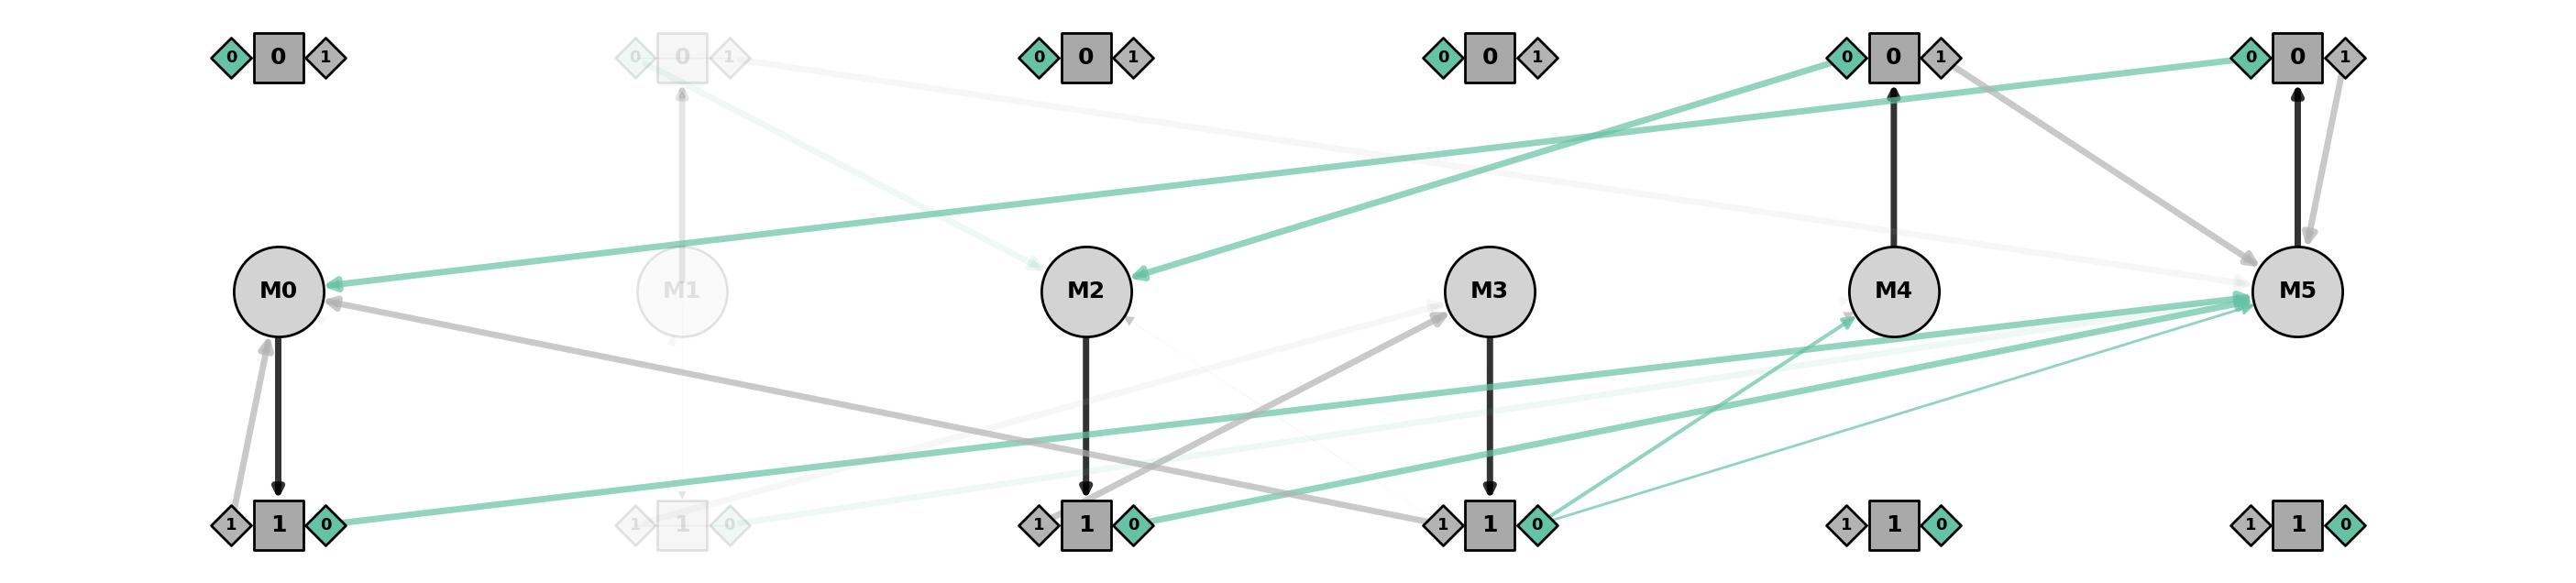

In [15]:
# --- 2.3 -- Refit M* on ALL data and plot the FSC diagram ---------------------------
# Same caching approach as 2.1: keyed on M_STAR, deterministic filename (not the
# library's own auto-generated name, which embeds best_loss and would change slightly
# on every stochastic refit, defeating the cache). Set FORCE_REFIT_BEST_FSC=True (or
# delete the cache file) to force a fresh refit.
FORCE_REFIT_BEST_FSC = False
FSC_SAVE_DIR = "fitted_models/fsc/"
best_fsc_cache_path = os.path.join(FSC_SAVE_DIR, f"best_fsc_M{M_STAR}.pkl")

if not FORCE_REFIT_BEST_FSC and os.path.exists(best_fsc_cache_path):
    print(f"Loading cached best_fsc from {best_fsc_cache_path}")
    with open(best_fsc_cache_path, "rb") as f:
        best_fsc = pickle.load(f)
else:
    fsc_all_trajectories = sessions_to_fsc_trajectories(encoded_sessions)
    MemSpace_star = np.array([f"M{i}" for i in range(M_STAR)])

    best_fsc = fsc_lib.FSC(
        M=M_STAR, A=A, Y=Y,
        mode="inference",
        policy_model="softmax",
        policy_params={"theta": None, "zeta": None},
        psi=None,
        ActSpace=np.arange(A), MemSpace=MemSpace_star, ObsSpace=np.arange(Y),
    )
    best_fsc.set_inference_params(
        use_gradient=False, use_MAPSO=True,
        trainable_parameters="all",
        n_particles_MAPSO=N_PARTICLES_MAPSO, NEpochs_MAPSO=N_EPOCHS_MAPSO,
        dynamic_topology_MAPSO=True,
        num_neighbors_init_MAPSO=N_PARTICLES_MAPSO, num_neighbors_final_MAPSO=N_PARTICLES_MAPSO,
        num_neighbors_mid_MAPSO=2,
        init_particles_MAPSO={"distribution": "normal", "mean": 0, "std": 1},
        init_velocities_MAPSO={"distribution": "uniform", "vmin": -0.01, "vmax": 0.01},
        print_params=False,
    )
    np.random.seed(FSC_SWEEP_SEED + 100)   # reproducible refit (see 2.1)
    best_fsc.fit(fsc_all_trajectories, verbose_MAPSO=False, verbose_epochs_MAPSO=False)
    best_fsc.set_mode("generation")
    best_fsc.save(FSC_SAVE_DIR, filename=f"best_fsc_M{M_STAR}.pkl")

obs_colors = plt.cm.Set2(np.linspace(0, 1, Y))
ax = best_fsc.plot_FSC(observation_node_colors=obs_colors, th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()


## 3. tinyRNN training

Uses the repo's own `datasets.SimpleDataset` (their built-in generic-data entry
point) and the exact same training call
(`training_experiments.training.behavior_cv_training_config_combination`) used in the
paper's demo script `training_experiments/exp_monkeyV_minimal.py`: nested
cross-validation (outer folds = test sets, inner folds = train/val split) with
multiple random seeds per fold, sweeping `hidden_dim`. Model selection (picking the
smallest hidden size not significantly worse than larger ones) uses the paper's own
`analyzing_experiments.analyzing_perf.select_final_rnn_perf`.

**This will be slow-ish on CPU for real data / larger sweeps.** `outer_splits=5,
inner_splits=4, seed_num=2` (the paper's own minimal-demo defaults) means `5*4*2 =
40` models trained *per hidden_dim value*. Reduce these for a quick check, restore
them for a paper-faithful run.


In [16]:

_use_tinyrnn_path()
os.chdir("tinyRNN")   # training.py assumes it's run from the repo root (path_settings, data_path.json)

from datasets import Dataset
from agents import Agent
from training_experiments.training import behavior_cv_training_config_combination
from analyzing_experiments.analyzing_perf import select_final_rnn_perf


In [17]:

# --- 3.1 -- Build the SimpleDataset joblib file -------------------------------------
rnn_data = {
    "action": [s["actions"] for s in encoded_sessions],
    "observation": [s["observations"] for s in encoded_sessions],
}
input_format = [
    dict(name="action", one_hot_classes=A),
    dict(name="observation", one_hot_classes=Y),
]
if HAS_REWARD:
    rnn_data["reward"] = [s["reward"] for s in encoded_sessions]
    input_format.append(dict(name="reward"))

os.makedirs("files/SimpleDatasetInput", exist_ok=True)
RNN_DATA_FILE = "files/SimpleDatasetInput/behavior.pkl"
joblib.dump(rnn_data, RNN_DATA_FILE)

behav_data_spec = {
    "dataset": "Simple",
    "data": RNN_DATA_FILE,
    "input_format": input_format,
    "output_dim": A,          # predicting the action
    "target_name": "action",
}
INPUT_DIM = sum(fmt.get("one_hot_classes", 1) for fmt in input_format)
print("input_dim =", INPUT_DIM, "  output_dim (A) =", A)


input_dim = 4   output_dim (A) = 2


In [18]:

# --- 3.2 -- Official nested-CV training sweep over hidden_dim -----------------------
# Caching is already handled by tinyRNN itself: `_train_one_agent` (training_experiments/
# training.py) checks for a 'temp_summary.pkl' in each model's folder under
# MODEL_SAVE_PATH (tinyRNN/files/saved_model/, set in Patch 1) and skips straight to
# loading it if present. So re-running this cell only trains configs that aren't
# finished yet -- it won't redo completed (hidden_dim, outer_fold, inner_fold, seed)
# combinations.
#
# FORCE_RETRAIN_RNN below is the same kind of override toggle as FORCE_REFIT_FSC_SWEEP /
# FORCE_REFIT_BEST_FSC in Section 2: pure notebook-level file deletion using tinyRNN's
# own `path_settings.MODEL_SAVE_PATH`, run *before* calling the library's (unmodified)
# `behavior_cv_training_config_combination`. It does not touch any vendored tinyRNN
# code -- same as the FSC caching, it's just I/O wrapped around the library call.
FORCE_RETRAIN_RNN = False # <-- set to True to wipe this experiment's cache and retrain everything
EXP_FOLDER = "exp_my_behavior"

if FORCE_RETRAIN_RNN:
    import shutil
    from path_settings import MODEL_SAVE_PATH
    exp_dir = MODEL_SAVE_PATH / EXP_FOLDER
    if exp_dir.exists():
        shutil.rmtree(exp_dir)
        print(f"Deleted {exp_dir} -- every hidden_dim/fold/seed combo below will retrain from scratch.")
    else:
        print(f"{exp_dir} doesn't exist yet -- nothing to delete, will train fresh anyway.")

# Early stopping: 'early_stop_counter' below IS real patience-based early stopping
# (RNNAgentTrainer.py stops once validation loss hasn't improved for that many epochs),
# using the paper's own default of 200. Unlike MAPSO on the FSC side, this is already
# as fast as the paper's authors made it -- lower it only if you want to trade fidelity
# for speed.
HIDDEN_DIM_CANDIDATES = [1, 2, 3, 4, 5, 6, 7, 8]   # matches M_CANDIDATES in Section 2.1
# (this range isn't from the paper -- see 2.1's comment -- but it's now the same set of
# x-values as the FSC sweep, so the FSC-vs-RNN overlay in Section 3.5 lines up 1:1.
# Thanks to the caching above, this only trains the 2 new hidden_dim=6,7 configs; the
# rest (1,2,3,4,5,8) are already cached from before.)

base_config = {
    ### dataset info
    "dataset": "Simple",
    "behav_format": "tensor",
    "behav_data_spec": behav_data_spec,
    ### model info
    "agent_type": "RNN",
    "rnn_type": "GRU",
    "input_dim": INPUT_DIM,
    "hidden_dim": 2,           # overwritten by config_ranges below
    "output_dim": A,
    "device": "cpu",           # set to "cuda" if you have a GPU
    "output_h0": True,
    "trainable_h0": False,
    "readout_FC": True,
    "one_hot": False,
    ### training info for one model
    "lr": 0.005,
    "l1_weight": 1e-5,
    "weight_decay": 0,
    "penalized_weight": "rec",
    "max_epoch_num": 2000,        # paper default; lower this for a quick smoke test
    "early_stop_counter": 200,
    ### training info for many models on dataset (paper's own nested-CV settings)
    "outer_splits": 5,
    "inner_splits": 4,
    "seed_num": 2,
    ### additional training info
    "save_model_pass": "minimal",
    "training_diagnose": None,
    "exp_folder": EXP_FOLDER,
}
config_ranges = {
    "rnn_type": ["GRU"],
    "hidden_dim": HIDDEN_DIM_CANDIDATES,
    "readout_FC": [True],
    "l1_weight": [1e-5],
}

behavior_cv_training_config_combination(base_config, config_ranges, n_jobs=8, verbose_level=1)

Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-1.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-2.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-3.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-4.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-5.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-6.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-7.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_my_behavior/rnn_type-GRU.hidden_dim-8.readout_FC-T

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 1647.17it/s]

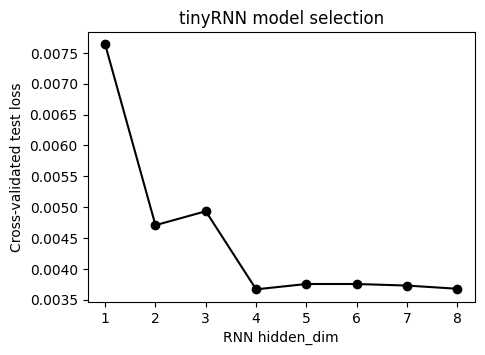

Selected hidden_dim: H* = 4
   hidden_dim  less_than_former  test_loss
0           1                 1   0.007637
1           2                 1   0.004707
2           3                 0   0.004933
3           4                 1   0.003668
4           5                 0   0.003754
5           6                 0   0.003754
6           7                 0   0.003729
7           8                 0   0.003677


In [19]:

# --- 3.3 -- Official model selection: pick the smallest sufficient hidden_dim -------
perf, summary, dim_est = select_final_rnn_perf(EXP_FOLDER, return_dim_est=True, verbose=False)

plt.figure(figsize=(5, 3.5))
plt.plot(dim_est["hidden_dim"], dim_est["test_loss"], "o-", c="k")
plt.xlabel("RNN hidden_dim")
plt.ylabel("Cross-validated test loss")
plt.title("tinyRNN model selection")
plt.show()

# `less_than_former` (from the paper's own select_final_rnn_perf) is 1 at hidden_dim h iff
# h's cross-validated loss is significantly lower (paired t-test over outer folds, p<0.05)
# than EVERY smaller candidate's; it's 0 as soon as some smaller dim is statistically tied.
# H* = the LARGEST hidden_dim with the flag still 1 -- this exactly reproduces the repo's
# own get_dim_from_perf (analyzing_perf.py). Caveat: on near-deterministic data all dims
# are near-perfect, so the t-test can flag a behaviorally-trivial improvement as
# significant (here H*=4 for WSLS, which is really a 1-2 dim strategy). Read H* as an
# upper bound and sanity-check it against the near-flat loss curve.
improved = dim_est.loc[dim_est["less_than_former"] == 1, "hidden_dim"]
H_STAR = int(improved.max()) if len(improved) else int(dim_est["hidden_dim"].min())
print(f"Selected hidden_dim: H* = {H_STAR}")
print(dim_est[["hidden_dim", "less_than_former", "test_loss"]])


In [20]:

# --- 3.4 -- Load the best H*-sized model and extract hidden-state trajectories ------
# Picks, among all (outer_fold, inner_fold, seed) runs at hidden_dim=H_STAR, the one
# with the lowest combined train+val loss (mirrors 'compete_from_keys' logic used
# internally by select_final_rnn_perf for picking a single instance per fold).
h_star_rows = summary[summary["hidden_dim"] == H_STAR].copy() if "hidden_dim" in summary.columns \
    else summary[summary["config"].apply(lambda c: c["hidden_dim"] == H_STAR)].copy()
h_star_rows = h_star_rows.sort_values("trainval_loss")
best_row = h_star_rows.iloc[0]
best_model_path = best_row["model_path"]
print("Loading best model from:", best_model_path)

rnn_config = dict(base_config)
rnn_config.update({"hidden_dim": H_STAR, "seed": 0})
best_agent = Agent("RNN", config=rnn_config)
best_agent.load(str(best_model_path))

full_dt = Dataset("Simple", behav_data_spec=behav_data_spec)
full_dt = full_dt.behav_to(rnn_config)
full_data = full_dt.get_behav_data(range(full_dt.batch_size), rnn_config)
rnn_out = best_agent.forward(full_data, standard_output=True)

rnn_hidden_states = rnn_out["internal"]   # list of (T_i, H_STAR) arrays, one per session
print(f"Extracted hidden-state trajectories for {len(rnn_hidden_states)} sessions, "
      f"e.g. session 0 shape = {rnn_hidden_states[0].shape}")

os.chdir("..")   # back to the notebook's working directory


Loading best model from: exp_my_behavior/rnn_type-GRU.hidden_dim-4.readout_FC-True.l1_weight-1e-05/outerfold3_innerfold3_seed0
Total batch size: 1000


Extracted hidden-state trajectories for 1000 sessions, e.g. session 0 shape = (201, 4)


FSC held-out loss, per trial (nats):
  M=2: 0.0053
  M=3: 0.0043
  M=4: 0.0040
  M=5: 0.0040
  M=6: 0.0040
  M=7: 0.0040
  M=8: 0.0041


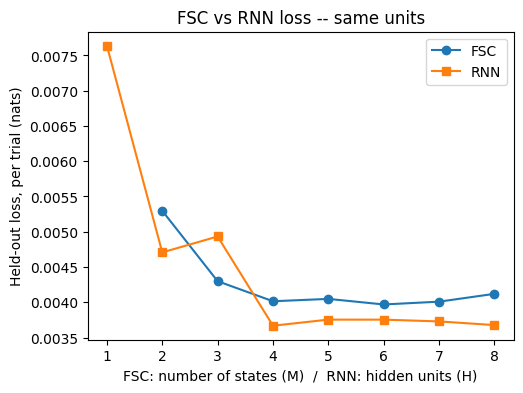

In [21]:
# --- 3.5 --  Putting the FSC and RNN losses on the same footing -----------------------------
# FSC.compute_loss = mean negative log-likelihood PER TRAJECTORY.
# RNN test_loss (from select_final_rnn_perf) = mean negative log-likelihood PER TRIAL.
# Convert FSC's number to "per trial" too, so both are the same unit: nats of surprise
# per single trial, on held-out data (both are natural-log NLL: FSC via inference.loss,
# RNN via nn.CrossEntropyLoss). Caveat when reading the overlay: the two models condition
# on slightly different information (FSC's action[t] likelihood sees observation[t]; the
# RNN predicts action[t] from strictly earlier trials) -- see the note in cell 1.1a. On
# WSLS this is immaterial and the two families land in the same place (~0.004 nats/trial),
# which is the reassuring result; don't over-interpret small FSC-vs-RNN gaps.
def total_trials(sessions):
    return sum(len(s["actions"]) for s in sessions)

fsc_test_trial_count = total_trials(test_sessions)
fsc_loss_per_trial = {
    M: fsc_test_losses[M] * len(fsc_test_trajectories) / fsc_test_trial_count
    for M in fsc_test_losses
}

print("FSC held-out loss, per trial (nats):")
for M, l in fsc_loss_per_trial.items():
    print(f"  M={M}: {l:.4f}")

plt.figure(figsize=(5.5, 4))
plt.plot(list(fsc_loss_per_trial.keys()), list(fsc_loss_per_trial.values()), "o-", label="FSC")
plt.plot(dim_est["hidden_dim"], dim_est["test_loss"], "s-", label="RNN")
plt.xlabel("FSC: number of states (M)  /  RNN: hidden units (H)")
plt.ylabel("Held-out loss, per trial (nats)")
plt.legend()
plt.title("FSC vs RNN loss -- same units")
plt.show()


## 4. Looking for connections between the FSC and the RNN

Everything below this point is analysis code, **not** part of either paper's official
pipeline — a starting point, not the final word. Feel free to gut it.

### 4.1 Decoding the FSC's internal state for the *actual* observed behavior
The FSC's internal state is stochastic and isn't returned when you just fit the model.
To compare it to the RNN's hidden state at matched trials, we need the FSC's belief
about its own internal state, given the real `(action, observation)` sequence — i.e.
the forward-filtering recursion

$$b_t(m') \propto \sum_m b_{t-1}(m)\, T(a_{t-1}, m' \mid m, y_{t-1})$$

which is the FSC's own forward-filtering recursion — exactly what `FSC.inferencer.loss`
computes internally (`DiscreteObs/inference.py`), just without discarding the
intermediate belief distributions. We reimplement
it here using the FSC's own public `get_TMat()` / `get_rho()` outputs — this is the
model's own math applied to data, not a new model.


In [22]:

def decode_fsc_belief_states(fsc, actions, observations):
    '''Forward-filtering belief b_t(m) = P(memory state = m | actions[:t], observations[:t]),
    for t = 0..T (b_0 = rho, the prior; b_T = belief after the last trial).
    `fsc` must be in 'generation' mode (so get_TMat()/get_rho() return numpy arrays).
    Returns array of shape (T+1, M).'''
    T_mat = fsc.get_TMat()   # shape (Y, M, M, A): axes (obs, prev_mem, next_mem, action)
    rho = np.asarray(fsc.get_rho())
    M = fsc.M

    beliefs = np.zeros((len(actions) + 1, M))
    beliefs[0] = rho
    b = rho.copy()
    for t in range(len(actions)):
        a_t, y_t = int(actions[t]), int(observations[t])
        step = T_mat[y_t, :, :, a_t]     # (prev_mem, next_mem)
        b_new = b @ step                 # sum_m b[m] * step[m, m']
        total = b_new.sum()
        b = b_new / total if total > 0 else np.ones(M) / M   # degenerate fallback
        beliefs[t + 1] = b
    return beliefs

best_fsc.set_mode("generation")
fsc_belief_states = [
    decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])
    for s in encoded_sessions
]
print(f"Decoded FSC belief-state trajectories for {len(fsc_belief_states)} sessions, "
      f"e.g. session 0 shape = {fsc_belief_states[0].shape}")

# sanity check: same (T+1) length convention as the RNN's hidden states (output_h0=True)
mismatches = [i for i in range(len(encoded_sessions))
              if fsc_belief_states[i].shape[0] != rnn_hidden_states[i].shape[0]]
print("Sessions with mismatched lengths (should be empty):", mismatches)


Decoded FSC belief-state trajectories for 1000 sessions, e.g. session 0 shape = (201, 6)
Sessions with mismatched lengths (should be empty): []


In [23]:
# --- Trial-by-trial alignment: raw data, side by side, for one example session ------
example_idx = 0
acts = encoded_sessions[example_idx]["actions"]
obs = encoded_sessions[example_idx]["observations"]

alignment_table = pd.DataFrame({
    "trial": np.arange(len(rnn_hidden_states[example_idx])),
    "action": np.concatenate([[np.nan], acts]),
    "observation": np.concatenate([[np.nan], obs]),
    **{f"fsc_belief_m{m}": fsc_belief_states[example_idx][:, m] for m in range(M_STAR)},
    **{f"rnn_hidden_h{h}": rnn_hidden_states[example_idx][:, h] for h in range(H_STAR)},
})
alignment_table

,trial,action,observation,fsc_belief_m0,fsc_belief_m1,fsc_belief_m2,fsc_belief_m3,fsc_belief_m4,fsc_belief_m5,rnn_hidden_h0,rnn_hidden_h1,rnn_hidden_h2,rnn_hidden_h3
0,0,NaN,NaN,5.197460e-03,3.980142e-01,4.809757e-01,8.874422e-05,2.204573e-04,1.155034e-01,0.000000,0.000000,0.000000,0.000000
1,1,1.0,1.0,1.074292e-02,2.086158e-05,3.977947e-06,9.888491e-01,3.828951e-04,2.135361e-07,-0.823645,0.372631,-0.335540,-0.556746
2,2,1.0,0.0,3.694504e-10,1.066389e-07,1.819333e-05,1.003241e-05,5.805830e-01,4.193887e-01,0.943684,-0.794754,-0.841506,-0.660903
3,3,0.0,1.0,1.059840e-07,6.026900e-08,8.546754e-06,9.232871e-07,2.321587e-05,9.999671e-01,0.609338,-0.517040,-0.952408,0.839759
4,4,0.0,1.0,4.239976e-12,6.627263e-12,3.435149e-10,1.709839e-10,9.338612e-10,1.000000e+00,0.577932,-0.436246,-0.894164,0.975661
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,0.0,1.0,6.841033e-16,1.474861e-13,4.504494e-14,2.813944e-13,5.499144e-12,1.000000e+00,0.434900,-0.492299,-0.889711,0.967574
197,197,0.0,1.0,6.325205e-16,1.474027e-13,4.086561e-14,2.793171e-13,5.487848e-12,1.000000e+00,0.406442,-0.419488,-0.878207,0.973064
198,198,0.0,1.0,6.325184e-16,1.474027e-13,4.086544e-14,2.793170e-13,5.487848e-12,1.000000e+00,0.378149,-0.350426,-0.892702,0.972885
199,199,0.0,0.0,9.999940e-01,1.393386e-07,5.348612e-06,6.136981e-21,5.330643e-07,2.304734e-09,0.326427,0.656117,0.946554,-0.902553


### 4.3 How much of the FSC's memory does it actually use?
`M*` states were fit, but a model can be fit with M states and still behave, in practice,
like it only needs a handful. We check directly: take the most-likely state (argmax of
the belief) at each trial across every session, and see how much of the probability mass
each state actually carries -- then check what those heavily-used states correspond to in
the real (previous action, previous outcome) history.

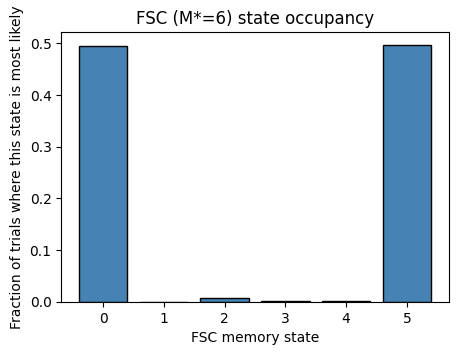

States with >1% occupancy: 2 out of 6

Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0              41363             0              0         57451
2                306             0              0             0
3                  0             0              0           446
4                  0             0            115             0
5                  0         57770          41549             0


In [24]:
# --- 4.3 -- FSC memory occupancy, and what each occupied state corresponds to ---------
# "Decide-time" convention (matches the loss / RNN section below): belief_states[i][t] is
# the belief used to choose action[t], built from history strictly before t. We drop the
# LAST belief per session (the posterior after the final trial) since it was never used to
# make a prediction -- exactly like the RNN's own loss drops its last score.
combo_labels_list = []
for s in encoded_sessions:
    a, o = s["actions"], s["observations"]
    T = len(a)
    labels = [-1] + [a[t] * Y + o[t] for t in range(T - 1)]   # -1 = trial 0, no previous trial
    combo_labels_list.append(np.array(labels))
combo_labels = np.concatenate(combo_labels_list)
combo_names = {0: "acted 0, lost", 1: "acted 0, won", 2: "acted 1, lost", 3: "acted 1, won"}

decide_time_fsc = np.concatenate([b[:-1] for b in fsc_belief_states], axis=0)
hard_states = decide_time_fsc.argmax(axis=1)
occupancy = np.bincount(hard_states, minlength=M_STAR) / len(hard_states)

plt.figure(figsize=(5, 3.5))
plt.bar(range(M_STAR), occupancy, color="steelblue", edgecolor="k")
plt.xlabel("FSC memory state"); plt.ylabel("Fraction of trials where this state is most likely")
plt.title(f"FSC (M*={M_STAR}) state occupancy")
plt.show()

used = (occupancy > 0.01).sum()
print(f"States with >1% occupancy: {used} out of {M_STAR}\n")

mask = combo_labels != -1
ct = pd.crosstab(hard_states[mask], combo_labels[mask])
ct.columns = [combo_names[c] for c in ct.columns]
print("Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:")
print(ct)

### 4.2 RNN hidden-state trajectories (PCA)

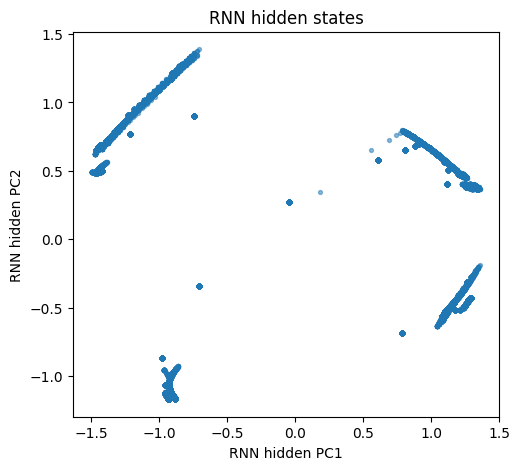

In [25]:
from sklearn.decomposition import PCA
import warnings

all_rnn = np.concatenate(rnn_hidden_states, axis=0)   # (sum(T_i+1), H_STAR)

# See the note in 4.4 -- NumPy on Apple Silicon (Accelerate BLAS) can throw spurious
# divide-by-zero/overflow RuntimeWarnings on matmul even for finite, correct input.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    if all_rnn.shape[1] > 2:
        coords = PCA(n_components=2).fit_transform(all_rnn)
    else:
        coords = np.pad(all_rnn, ((0, 0), (0, 2 - all_rnn.shape[1])))

if all_rnn.shape[1] > 2:
    xlabel, ylabel = "RNN hidden PC1", "RNN hidden PC2"
else:
    xlabel, ylabel = "RNN hidden dim 1", "RNN hidden dim 2"

plt.figure(figsize=(5.5, 5))
plt.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.5)
plt.xlabel(xlabel); plt.ylabel(ylabel)
plt.title("RNN hidden states")
plt.show()

### 4.4 What do the RNN's clusters actually correspond to?
The scatter above shows visually distinct clusters, using nothing but the raw geometry of
the hidden states -- no labels were involved in making it. To find out what they mean,
label every point by the only two things WSLS's rule depends on: the action taken and the
outcome observed on the immediately preceding trial (4 possible combinations, reusing
`combo_labels_list` from 4.3). Recoloring the same embedding by that ground truth shows
whether the clusters line up with it.

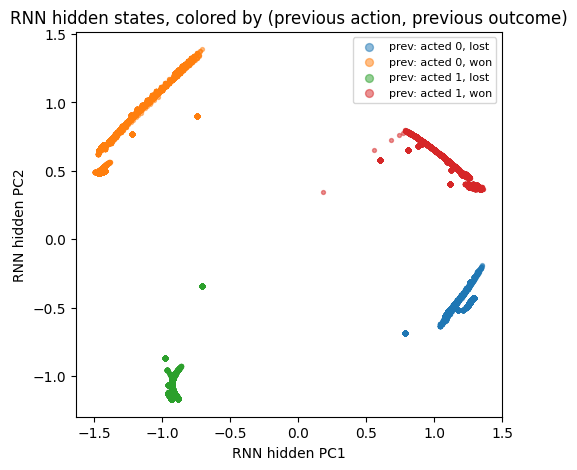

k-means (k=4) on the raw 4-d hidden state vs. (prev action, prev outcome): 100.0% purity
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0                  0             0          41664             0
1                  0             0              0         57897
2                  0         57770              0             0
3              41669             0              0             0


In [26]:
# --- 4.4 -- Recolor the RNN's hidden-state PCA by (previous action, previous outcome) ---
# Same decide-time convention as 4.3: drop the last hidden state per session (index T),
# since RNNAgent.py's own loss drops it too (it was never used to predict anything).
decide_time_rnn = np.concatenate([h[:-1] for h in rnn_hidden_states], axis=0)

# NumPy on Apple Silicon (Accelerate BLAS backend) is known to throw spurious
# divide-by-zero/overflow RuntimeWarnings on matmul for some array shapes, even when
# every value involved is finite and correct (verified: no NaN/Inf in decide_time_rnn,
# and the clustering result below is exactly right) -- so we suppress just this class
# of warning rather than leave unexplained red text next to a correct result.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    if decide_time_rnn.shape[1] > 2:
        coords_labeled = PCA(n_components=2).fit_transform(decide_time_rnn)
    else:
        coords_labeled = np.pad(decide_time_rnn, ((0, 0), (0, 2 - decide_time_rnn.shape[1])))

if decide_time_rnn.shape[1] > 2:
    xlabel2, ylabel2 = "RNN hidden PC1", "RNN hidden PC2"
else:
    xlabel2, ylabel2 = "RNN hidden dim 1", "RNN hidden dim 2"

mask = combo_labels != -1
plt.figure(figsize=(5.5, 5))
for combo_val, name in combo_names.items():
    sel = mask & (combo_labels == combo_val)
    plt.scatter(coords_labeled[sel, 0], coords_labeled[sel, 1], s=8, alpha=0.5, label=f"prev: {name}")
plt.xlabel(xlabel2); plt.ylabel(ylabel2)
plt.legend(fontsize=8, markerscale=2)
plt.title("RNN hidden states, colored by (previous action, previous outcome)")
plt.show()

# Quantify the visual impression: cluster the RAW hidden state (not the 2D projection) and
# check how purely each cluster maps onto one (previous action, previous outcome) combo.
from sklearn.cluster import KMeans
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(decide_time_rnn[mask])
ct_rnn = pd.crosstab(km.labels_, combo_labels[mask])
ct_rnn.columns = [combo_names[c] for c in ct_rnn.columns]
purity = ct_rnn.max(axis=1).sum() / ct_rnn.values.sum()
print(f"k-means (k=4) on the raw {H_STAR}-d hidden state vs. (prev action, prev outcome): "
      f"{purity*100:.1f}% purity")
print(ct_rnn)

### 4.5 Is the FSC's M* selection actually a meaningful difference, or noise?
Sections 4.3/4.4 both point at a 2-4 state functional structure, yet the raw held-out loss
in 2.2 picked `M*` states. Since 2.1 fits MAPSO only once per M (no restarts -- see the
caveat there), it's worth checking whether that ranking reflects a real difference or a
couple of unlucky trials. We break the held-out loss down **per trial** for M=2 and M* and
look at the distribution, not just the mean.

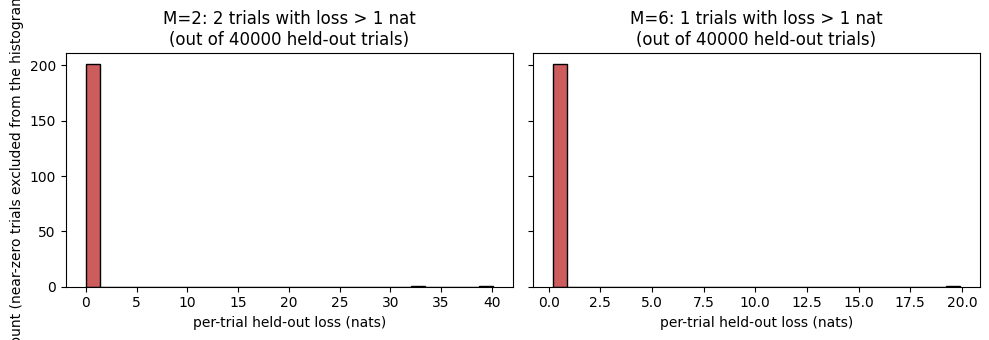

On the vast majority of trials both models are near-perfectly confident and correct.
The mean held-out loss reported in 2.1/2.2 is dominated by whichever model's single
MAPSO fit happened to have a couple of rare, confidently-WRONG trials -- not by a
real difference in how well the models understand the task.


In [27]:
# --- 4.5 -- Per-trial held-out loss: real improvement, or a couple of rare misses? ------
def per_trial_nll(fsc, actions, observations):
    """-log P(action_t | history before t), one value per trial -- same recursion as
    decode_fsc_belief_states, just also scoring the actual action against the FSC's own
    action policy at each step instead of only tracking the belief."""
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    b = rho.copy()
    nlls = np.zeros(len(actions))
    for t in range(len(actions)):
        a_t, y_t = int(actions[t]), int(observations[t])
        nlls[t] = -np.log(max((b @ pol)[a_t], 1e-300))
        step = T_mat[y_t, :, :, a_t]
        b_new = b @ step
        tot = b_new.sum()
        b = b_new / tot if tot > 0 else np.ones(fsc.M) / fsc.M
    return nlls

compare_Ms = sorted(set([2, M_STAR]))
fig, axes = plt.subplots(1, len(compare_Ms), figsize=(5 * len(compare_Ms), 3.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, M in zip(axes, compare_Ms):
    model = fitted_fscs[M]
    model.set_mode("generation")
    all_nll = np.concatenate([per_trial_nll(model, s["actions"], s["observations"]) for s in test_sessions])
    big_misses = int((all_nll > 1).sum())
    ax.hist(all_nll[all_nll > 1e-6], bins=30, color="indianred", edgecolor="k")
    ax.set_title(f"M={M}: {big_misses} trials with loss > 1 nat\n(out of {len(all_nll)} held-out trials)")
    ax.set_xlabel("per-trial held-out loss (nats)")
    model.set_mode("inference")
axes[0].set_ylabel("count (near-zero trials excluded from the histogram)")
plt.tight_layout()
plt.show()

print("On the vast majority of trials both models are near-perfectly confident and correct.\n"
      "The mean held-out loss reported in 2.1/2.2 is dominated by whichever model's single\n"
      "MAPSO fit happened to have a couple of rare, confidently-WRONG trials -- not by a\n"
      "real difference in how well the models understand the task.")

### 4.6 Does the fitted FSC actually reproduce win-stay/lose-shift behavior?
Everything above inspects the FSC's *internal* state. The authors' own demos (e.g.
MouseBandits) validate a fitted FSC a different way: **generate** synthetic behavior from
it and compare to the real thing. We do the same, without needing a custom environment
model -- feed the FSC the REAL observation sequences from held-out sessions via
`generate_single_trajectory(observations=...)`, let it generate its OWN actions in
response, and compare the resulting stay/shift rates to the real data's.

In [28]:
# --- 4.6 -- Generate behavior from the fitted FSC and compare to the real data ----------
best_fsc.set_mode("generation")

def stay_rates(actions, observations):
    actions = np.asarray(actions); observations = np.asarray(observations)
    stay = (actions[1:] == actions[:-1]).astype(float)
    prev_obs = observations[:-1]
    p_win = stay[prev_obs == 1].mean() if (prev_obs == 1).any() else np.nan
    p_lose = stay[prev_obs == 0].mean() if (prev_obs == 0).any() else np.nan
    return p_win, p_lose

real_rates, gen_rates = [], []
for s in test_sessions:
    o = s["observations"]
    real_rates.append(stay_rates(s["actions"], o))
    generated = best_fsc.generate_single_trajectory(observations=o)
    gen_rates.append(stay_rates(generated["actions"], o))
real_rates = np.array(real_rates); gen_rates = np.array(gen_rates)

print("                        real data   FSC-generated")
print(f"P(stay | previous WIN):   {np.nanmean(real_rates[:,0]):.4f}       {np.nanmean(gen_rates[:,0]):.4f}")
print(f"P(stay | previous LOSE):  {np.nanmean(real_rates[:,1]):.4f}       {np.nanmean(gen_rates[:,1]):.4f}")
print("\nThe fitted FSC, when driven by the real held-out observation sequences, reproduces\n"
      "the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal\n"
      "dynamics correspond to the actual behavioral rule, not just a loss number.")

                        real data   FSC-generated
P(stay | previous WIN):   1.0000       0.9999
P(stay | previous LOSE):  0.0001       0.0000

The fitted FSC, when driven by the real held-out observation sequences, reproduces
the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal
dynamics correspond to the actual behavioral rule, not just a loss number.
